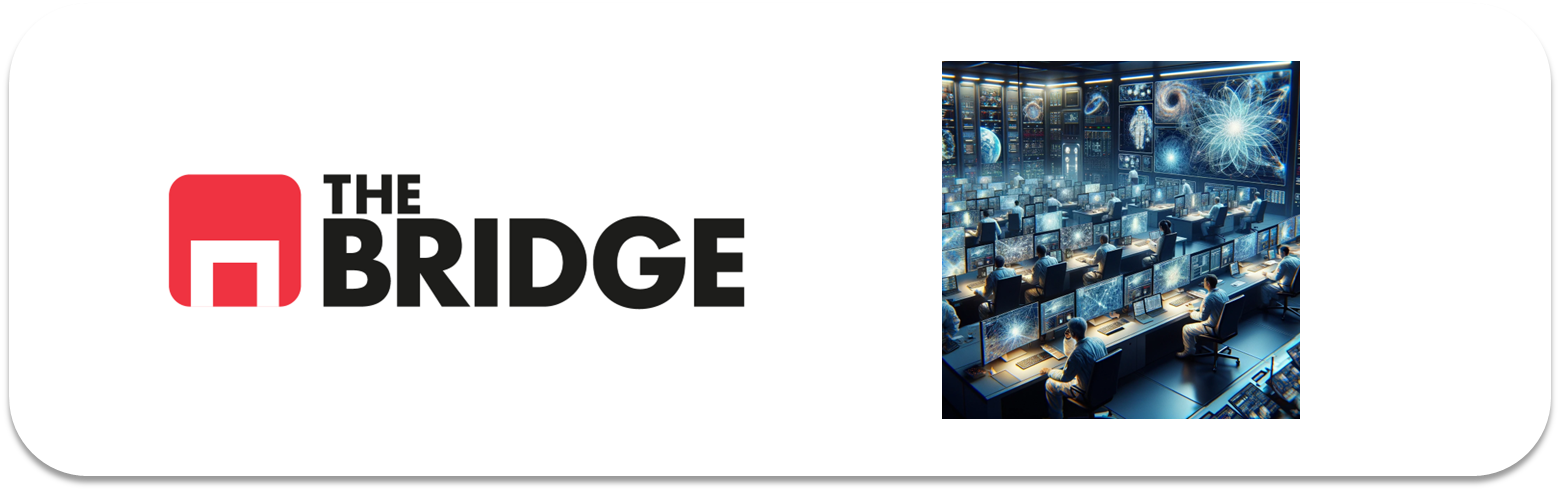

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [2]:
# Generación de datos 

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "data/seg_train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    "data/seg_test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 14034 images belonging to 1 classes.
Found 3000 images belonging to 1 classes.


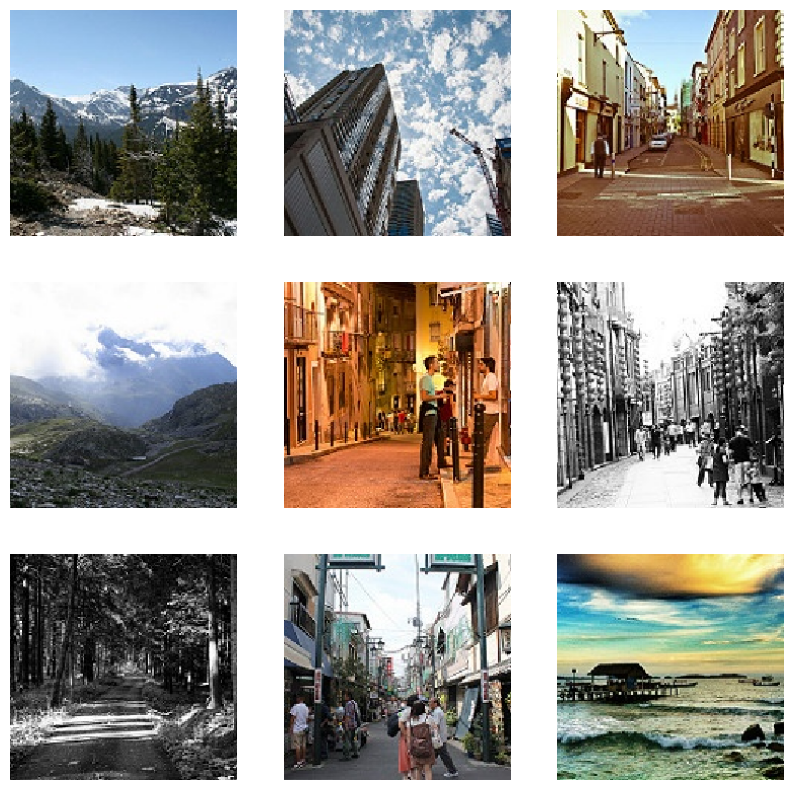

In [3]:
# Visualización rapida 

def plot_images(generator):
    x, y = next(generator)
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(x[i])
        plt.axis("off")
    plt.show()

plot_images(train_gen)

In [4]:
# Modelo base: VGG19

base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Transfer Learning
# Cabeza (máx 2 densas ocultas)

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)

output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [6]:
# Compilación 

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# Entrenamiento

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen
)

Epoch 1/10


c:\Users\rukas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\rukas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


439/439 ━━━━━━━━━━━━━━━━━━━━ 2892s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 2888s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 3910s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 4172s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 2995s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 2531s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 3562s 8s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 3452s

In [8]:
# Evaluación

loss, acc = model.evaluate(test_gen)
print(f"Test accuracy: {acc}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 502s 5s/step - accuracy: 1.0000 - loss: 0.0000e+00
Test accuracy: 1.0


In [10]:
# Classification report 

y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

c:\Users\rukas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


94/94 ━━━━━━━━━━━━━━━━━━━━ 482s 5s/step
              precision    recall  f1-score   support

    seg_test       1.00      1.00      1.00      3000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



c:\Users\rukas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


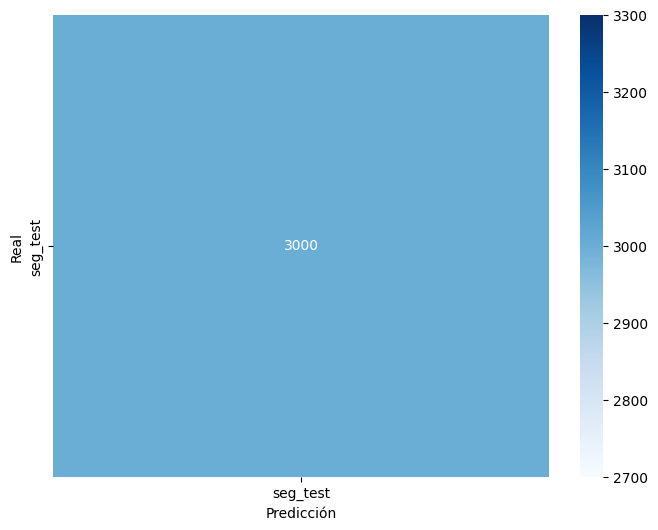

In [11]:
# matriz de confusión

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [12]:
# Fine-Tuning

base_model.trainable = True

# Congelar la mayoría y dejar solo últimas capas
for layer in base_model.layers[:-4]:
    layer.trainable = False

In [13]:
# Recompilar 
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenar de nuevo

history_fine = model.fit(
    train_gen,
    epochs=5,
    validation_data=test_gen
)

In [ ]:
# Evaluación final 

loss, acc = model.evaluate(test_gen)
print(f"Fine-tuned Test accuracy: {acc}")